In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

dataset_url = "https://raw.githubusercontent.com/ToufiqImrose/AI-ML/main/AI_ML/decision%20tree/Dataset/breast-cancer.csv"

df = pd.read_csv(dataset_url, na_values=['?'])
df.head()



,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
# Data Preprocessing

# Drop the 'id' column as it is not needed for the model
df = df.drop('id', axis=1)


print("\nMissing values before handling:\n", df.isnull().sum())

# Let's check again for any remaining NaNs in numerical columns and impute with the mean if found.
for col in df.columns:
    if df[col].dtype == 'object':
        if df[col].isnull().any():
            df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        if df[col].isnull().any():
            df[col].fillna(df[col].mean(), inplace=True)

print("\nMissing values after handling:\n", df.isnull().sum())

# Encode categorical feature 'diagnosis' (M=Malignant, B=Benign)
label_encoder = LabelEncoder()
df['diagnosis'] = label_encoder.fit_transform(df['diagnosis'])
print("\n'diagnosis' column after encoding:")
print(df['diagnosis'].value_counts())

# Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Using a common split ratio, e.g., 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")



Missing values before handling:
 diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Missing values after handling:
 diagnosis            

In [3]:
# CART (Gini) Implementation and Tuning

param_grid_cart = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20]
}

# Initialize the Decision Tree Classifier with Gini criterion
cart_tree = DecisionTreeClassifier(criterion='gini', random_state=42)

# Initialize GridSearchCV
grid_search_cart = GridSearchCV(cart_tree, param_grid_cart, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_cart.fit(X_train, y_train)

# Get the best parameters and best score
best_params_cart = grid_search_cart.best_params_
best_score_cart = grid_search_cart.best_score_

print("\nCART (Gini) - Best Hyperparameters:", best_params_cart)
print("CART (Gini) - Best Cross-validation Accuracy:", f"{best_score_cart:.4f}")

# Train the optimized CART model on the full training data
optimized_cart_model = DecisionTreeClassifier(criterion='gini', random_state=42, **best_params_cart)
optimized_cart_model.fit(X_train, y_train)

print("\nOptimized CART model trained successfully.")



CART (Gini) - Best Hyperparameters: {'max_depth': None, 'min_samples_split': 5}
CART (Gini) - Best Cross-validation Accuracy: 0.9385

Optimized CART model trained successfully.


In [4]:
# ID3 (Entropy) Implementation and Tuning

param_grid_id3 = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20]
}

# Initialize the Decision Tree Classifier with Entropy criterion
id3_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Initialize GridSearchCV
grid_search_id3 = GridSearchCV(id3_tree, param_grid_id3, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_id3.fit(X_train, y_train)

# Get the best parameters and best score
best_params_id3 = grid_search_id3.best_params_
best_score_id3 = grid_search_id3.best_score_

print("\nID3 (Entropy) - Best Hyperparameters:", best_params_id3)
print("ID3 (Entropy) - Best Cross-validation Accuracy:", f"{best_score_id3:.4f}")

# Train the optimized ID3 model on the full training data
optimized_id3_model = DecisionTreeClassifier(criterion='entropy', random_state=42, **best_params_id3)
optimized_id3_model.fit(X_train, y_train)

print("\nOptimized ID3 model trained successfully.")



ID3 (Entropy) - Best Hyperparameters: {'max_depth': None, 'min_samples_split': 5}
ID3 (Entropy) - Best Cross-validation Accuracy: 0.9451

Optimized ID3 model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


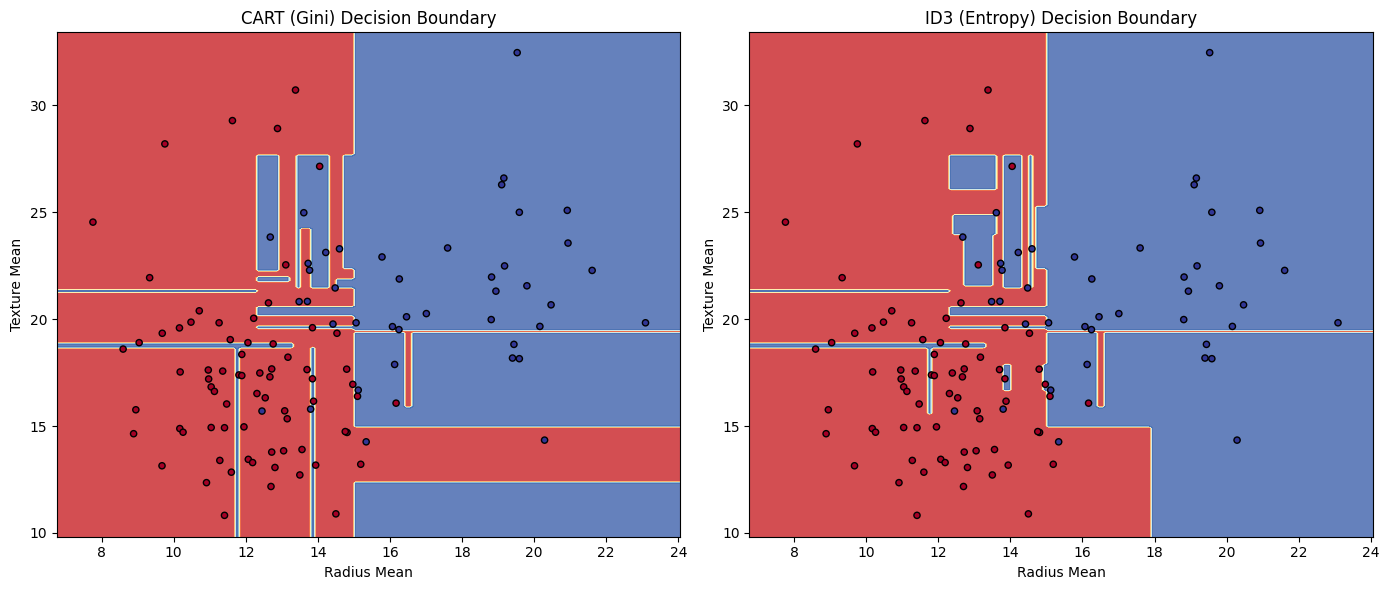

In [5]:

# Select the two features for plotting
X_plot = X_test[['radius_mean', 'texture_mean']]
y_plot = y_test

# Create a meshgrid for plotting decision boundaries
x_min, x_max = X_plot.iloc[:, 0].min() - 1, X_plot.iloc[:, 0].max() + 1
y_min, y_max = X_plot.iloc[:, 1].min() - 1, X_plot.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                       np.arange(y_min, y_max, 0.1))

# Helper function to plot decision boundaries for a given model
def plot_decision_boundary(ax, model, X_train_full, y_train_full, X_plot_features, title):

    temp_model = DecisionTreeClassifier(criterion=model.criterion, random_state=42,
                                        max_depth=model.max_depth,
                                        min_samples_split=model.min_samples_split)

    # Identify column indices of selected features in the original X_train
    feature_names = ['radius_mean', 'texture_mean']
    feature_indices = [X_train_full.columns.get_loc(col) for col in feature_names]
    X_train_2d = X_train_full.iloc[:, feature_indices]

    temp_model.fit(X_train_2d, y_train_full)

    Z = temp_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    ax.scatter(X_plot_features.iloc[:, 0], X_plot_features.iloc[:, 1], c=y_plot, cmap=plt.cm.RdYlBu, edgecolors='black', s=20)
    ax.set_xlabel('Radius Mean')
    ax.set_ylabel('Texture Mean')
    ax.set_title(title)

# Create the 2x1 matrix for decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot CART Decision Boundary
plot_decision_boundary(axes[0], optimized_cart_model, X_train, y_train, X_plot, 'CART (Gini) Decision Boundary')

# Plot ID3 Decision Boundary
plot_decision_boundary(axes[1], optimized_id3_model, X_train, y_train, X_plot, 'ID3 (Entropy) Decision Boundary')

plt.tight_layout()
plt.show()


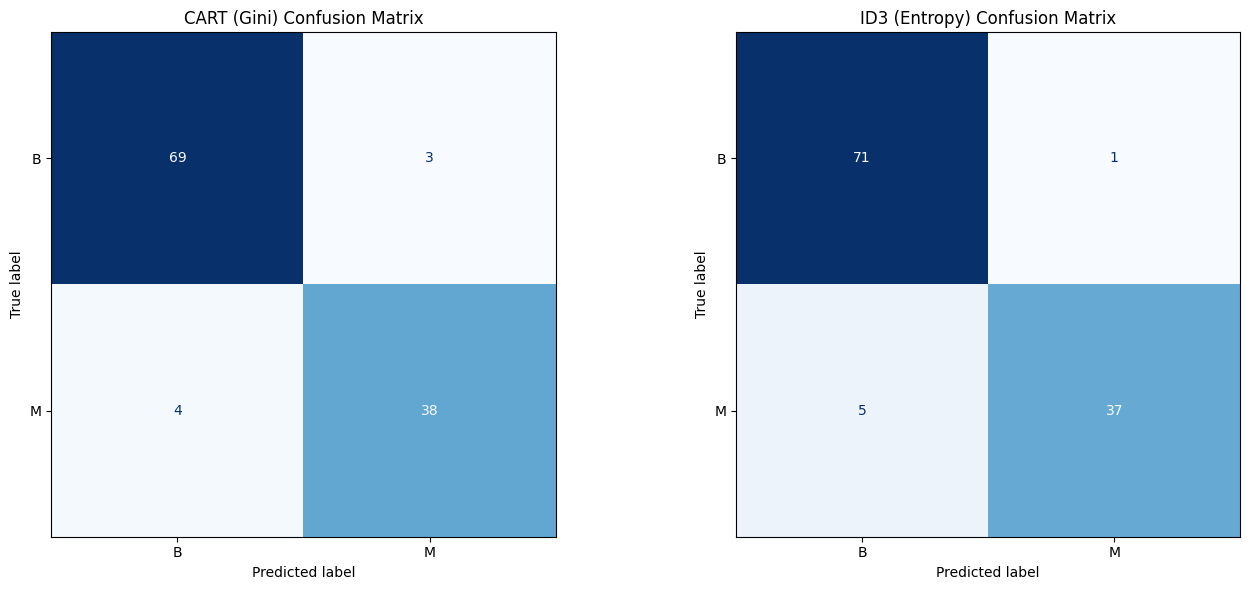

In [6]:
# 2. Confusion Matrix Heatmap visualization 2x1 Matrix

# Make predictions on the test set for both models
y_pred_cart = optimized_cart_model.predict(X_test)
y_pred_id3 = optimized_id3_model.predict(X_test)

# Create the 2x1 matrix for confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Confusion Matrix for CART
cm_cart = confusion_matrix(y_test, y_pred_cart)
display_cart = ConfusionMatrixDisplay(confusion_matrix=cm_cart, display_labels=label_encoder.classes_)
display_cart.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('CART (Gini) Confusion Matrix')

# Plot Confusion Matrix for ID3
cm_id3 = confusion_matrix(y_test, y_pred_id3)
display_id3 = ConfusionMatrixDisplay(confusion_matrix=cm_id3, display_labels=label_encoder.classes_)
display_id3.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('ID3 (Entropy) Confusion Matrix')

plt.tight_layout()
plt.show()


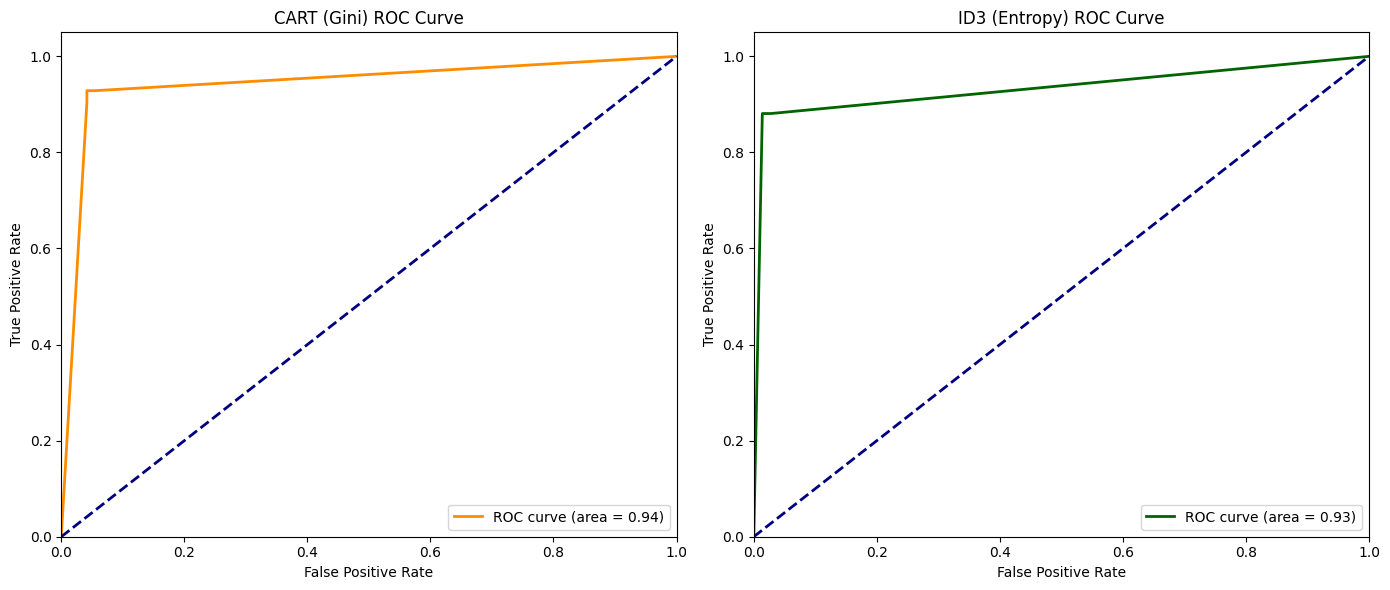

In [7]:
# 3. ROC Curve Plot

y_prob_cart = optimized_cart_model.predict_proba(X_test)[:, 1]
y_prob_id3 = optimized_id3_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_cart, tpr_cart, _ = roc_curve(y_test, y_prob_cart)
auc_cart = auc(fpr_cart, tpr_cart)

fpr_id3, tpr_id3, _ = roc_curve(y_test, y_prob_id3)
auc_id3 = auc(fpr_id3, tpr_id3)

# Create the 2x1 matrix for ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot ROC Curve for CART
axes[0].plot(fpr_cart, tpr_cart, color='darkorange', lw=2, label=f'ROC curve (area = {auc_cart:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('CART (Gini) ROC Curve')
axes[0].legend(loc='lower right')

# Plot ROC Curve for ID3
axes[1].plot(fpr_id3, tpr_id3, color='darkgreen', lw=2, label=f'ROC curve (area = {auc_id3:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ID3 (Entropy) ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()



Evaluation Metrics:
      Metric  CART (Gini)  ID3 (Entropy)
0   Accuracy       0.9386         0.9474
1  Precision       0.9268         0.9737
2     Recall       0.9048         0.8810
3   F1-Score       0.9157         0.9250
4        AUC       0.9425         0.9327


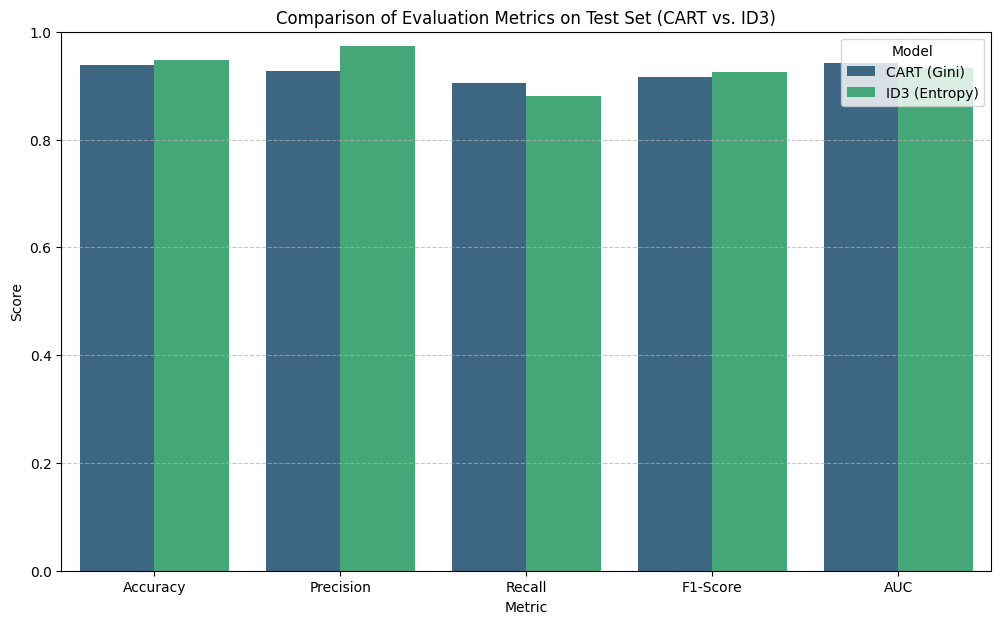

In [8]:
# 4. Evaluation Metrics Bar Chart (Accuracy, Precision, Recall, F1, AUC) - Combined chart comparing both models

y_pred_cart = optimized_cart_model.predict(X_test)
y_pred_id3 = optimized_id3_model.predict(X_test)

# Calculate metrics for CART
accuracy_cart = accuracy_score(y_test, y_pred_cart)
precision_cart = precision_score(y_test, y_pred_cart)
recall_cart = recall_score(y_test, y_pred_cart)
f1_cart = f1_score(y_test, y_pred_cart)
# AUC for CART was calculated during ROC curve plotting: auc_cart

accuracy_id3 = accuracy_score(y_test, y_pred_id3)
precision_id3 = precision_score(y_test, y_pred_id3)
recall_id3 = recall_score(y_test, y_pred_id3)
f1_id3 = f1_score(y_test, y_pred_id3)


# Create a DataFrame to store the metrics for easier plotting
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'CART (Gini)': [accuracy_cart, precision_cart, recall_cart, f1_cart, auc_cart],
    'ID3 (Entropy)': [accuracy_id3, precision_id3, recall_id3, f1_id3, auc_id3]
}
metrics_df = pd.DataFrame(metrics_data)

print("\nEvaluation Metrics:")
print(metrics_df.round(4))

# Plotting the combined bar chart
metrics_df_melted = metrics_df.melt('Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Evaluation Metrics on Test Set (CART vs. ID3)')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


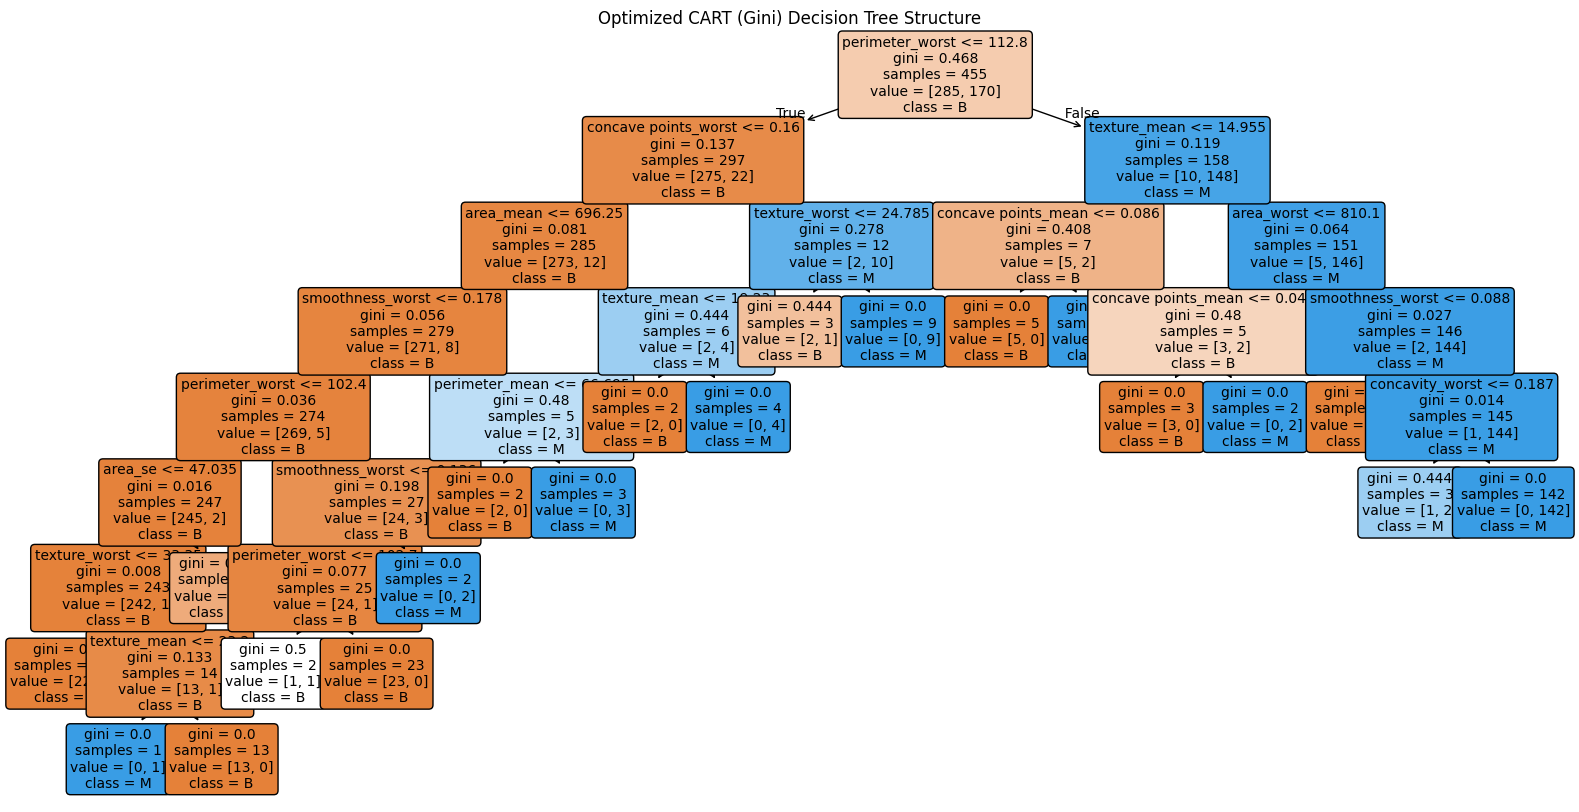

In [9]:
# 5. DT Structure Visualization of optimized tree structure Single image showing tree structure

plt.figure(figsize=(20, 10))
plot_tree(optimized_cart_model,
          feature_names=X.columns.tolist(),
          class_names=label_encoder.classes_.tolist(), # 'B' for Benign, 'M' for Malignant
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Optimized CART (Gini) Decision Tree Structure')
plt.show()


